In [1]:
import sys
!{sys.executable} -m pip install SimpleITK

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

def analyze_images():
    """Step 1: Analyze the images to understand their properties"""
    # Load images
    fixed_image = sitk.ReadImage('chestctdata/01_Fixed.mhd')
    moving_image = sitk.ReadImage('chestctdata/01_Moving.mhd')

    print("=== IMAGE ANALYSIS ===")
    print(f"Fixed Image:")
    print(f"  Size: {fixed_image.GetSize()}")
    print(f"  Spacing: {fixed_image.GetSpacing()}")
    print(f"  Origin: {fixed_image.GetOrigin()}")
    print(f"  Pixel Type: {fixed_image.GetPixelIDTypeAsString()}")

    print(f"\nMoving Image:")
    print(f"  Size: {moving_image.GetSize()}")
    print(f"  Spacing: {moving_image.GetSpacing()}")
    print(f"  Origin: {moving_image.GetOrigin()}")
    print(f"  Pixel Type: {moving_image.GetPixelIDTypeAsString()}")

    return fixed_image, moving_image

# Run analysis
fixed, moving = analyze_images()

=== IMAGE ANALYSIS ===
Fixed Image:
  Size: (418, 368, 323)
  Spacing: (0.683594, 0.683594, 0.7)
  Origin: (0.0, 0.0, 0.0)
  Pixel Type: 16-bit signed integer

Moving Image:
  Size: (462, 386, 412)
  Spacing: (0.679688, 0.679688, 0.7)
  Origin: (0.0, 0.0, 0.0)
  Pixel Type: 16-bit signed integer


In [3]:
def resample_to_common_space(fixed_image, moving_image):
    """Step 2: Resample moving image to fixed image space"""
    print("\n=== RESAMPLING TO COMMON SPACE ===")

    # Convert to float32 for registration
    fixed_float = sitk.Cast(fixed_image, sitk.sitkFloat32)
    moving_float = sitk.Cast(moving_image, sitk.sitkFloat32)

    print(f"Fixed image spacing: {fixed_float.GetSpacing()}")
    print(f"Moving image spacing: {moving_float.GetSpacing()}")

    # Create resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed_float)  # Use fixed image as reference
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)  # CT air value

    # Resample moving image to fixed image space
    moving_resampled = resampler.Execute(moving_float)

    print(f"Moving image resampled from {moving_float.GetSize()} to: {moving_resampled.GetSize()}")
    print(f"Now both images have same size: {fixed_float.GetSize()} == {moving_resampled.GetSize()}")
    print(f"And same spacing: {fixed_float.GetSpacing()} == {moving_resampled.GetSpacing()}")

    return fixed_float, moving_resampled

# Continue from Step 1
print("\n" + "="*50)
print("STEP 2: Resampling to Common Space")
print("="*50)

fixed_common, moving_common = resample_to_common_space(fixed, moving)


STEP 2: Resampling to Common Space

=== RESAMPLING TO COMMON SPACE ===
Fixed image spacing: (0.683594, 0.683594, 0.7)
Moving image spacing: (0.679688, 0.679688, 0.7)
Moving image resampled from (462, 386, 412) to: (418, 368, 323)
Now both images have same size: (418, 368, 323) == (418, 368, 323)
And same spacing: (0.683594, 0.683594, 0.7) == (0.683594, 0.683594, 0.7)


In [4]:
def apply_lung_masks(fixed_image, moving_image):
    """Step 3: Apply lung masks to isolate lung regions"""
    print("\n=== APPLYING LUNG MASKS ===")

    # Load masks
    fixed_mask = sitk.ReadImage('lungMasks/01_Fixed.mhd')
    moving_mask = sitk.ReadImage('lungMasks/01_Moving.mhd')

    print(f"Fixed mask size: {fixed_mask.GetSize()}")
    print(f"Moving mask size: {moving_mask.GetSize()}")

    # Resample moving mask to fixed image space (same as we did for the moving image)
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed_image)  # Use fixed image as reference
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)  # Important: use nearest neighbor for masks
    resampler.SetDefaultPixelValue(0)
    moving_mask_resampled = resampler.Execute(moving_mask)

    print(f"Moving mask resampled to: {moving_mask_resampled.GetSize()}")

    # Apply masks to isolate lung regions
    fixed_lung = sitk.Mask(fixed_image, fixed_mask)
    moving_lung = sitk.Mask(moving_image, moving_mask_resampled)

    print("Lung masks applied successfully!")

    # Save masked images
    sitk.WriteImage(fixed_lung, 'fixed_lung_masked.mhd')
    sitk.WriteImage(moving_lung, 'moving_lung_masked.mhd')
    print("Masked images saved as 'fixed_lung_masked.mhd' and 'moving_lung_masked.mhd'")

    return fixed_lung, moving_lung

# Continue with Step 3
print("\n" + "="*50)
print("STEP 3: Applying Lung Masks")
print("="*50)

fixed_lung, moving_lung = apply_lung_masks(fixed_common, moving_common)


STEP 3: Applying Lung Masks

=== APPLYING LUNG MASKS ===
Fixed mask size: (418, 368, 323)
Moving mask size: (462, 386, 412)
Moving mask resampled to: (418, 368, 323)
Lung masks applied successfully!
Masked images saved as 'fixed_lung_masked.mhd' and 'moving_lung_masked.mhd'


In [7]:
def affine_registration(fixed_image, moving_image):
    """Step 4: Perform affine registration for initial alignment"""
    print("\n=== AFFINE REGISTRATION ===")

    # Set up registration
    registration_method = sitk.ImageRegistrationMethod()

    # Similarity metric - Mutual Information works well for medical images
    registration_method.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)

    # Optimizer
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=1.0,  # Conservative learning rate
        minStep=1e-4,
        numberOfIterations=100,  #
        relaxationFactor=0.5
    )
    registration_method.SetOptimizerScalesFromPhysicalShift()

    # Initial transform - center the images
    initial_transform = sitk.CenteredTransformInitializer(
        fixed_image,
        moving_image,
        sitk.AffineTransform(3)
    )

    registration_method.SetInitialTransform(initial_transform)
    registration_method.SetInterpolator(sitk.sitkLinear)

    # Print progress
    registration_method.AddCommand(sitk.sitkIterationEvent,
                                 lambda: print(f"  Iteration: {registration_method.GetOptimizerIteration()}, "
                                             f"Metric: {registration_method.GetMetricValue():.6f}"))

    print("Running affine registration...")
    final_transform = registration_method.Execute(fixed_image, moving_image)

    print(f"✓ Affine registration completed!")
    print(f"  Final metric value: {registration_method.GetMetricValue():.6f}")
    print(f"  Iterations: {registration_method.GetOptimizerIteration()}")

    return final_transform

# Continue with Step 4
print("\n" + "="*50)
print("STEP 4: Affine Registration")
print("="*50)

affine_transform = affine_registration(fixed_lung, moving_lung)

# Apply affine transformation to see intermediate result
print("\nApplying affine transformation...")
moving_affine = sitk.Resample(moving_lung, fixed_lung, affine_transform)
sitk.WriteImage(moving_affine, 'moving_affine_registered.mhd')
print("Affine-registered image saved as 'moving_affine_registered.mhd'")


STEP 4: Affine Registration

=== AFFINE REGISTRATION ===
Running affine registration...
  Iteration: 0, Metric: -0.168955
  Iteration: 1, Metric: -0.178351
  Iteration: 2, Metric: -0.187372
  Iteration: 3, Metric: -0.197128
  Iteration: 4, Metric: -0.207846
  Iteration: 5, Metric: -0.218883
  Iteration: 6, Metric: -0.230442
  Iteration: 7, Metric: -0.242873
  Iteration: 8, Metric: -0.255183
  Iteration: 9, Metric: -0.267022
  Iteration: 10, Metric: -0.278889
  Iteration: 11, Metric: -0.290900
  Iteration: 12, Metric: -0.304757
  Iteration: 13, Metric: -0.312225
  Iteration: 14, Metric: -0.320443
  Iteration: 15, Metric: -0.328221
  Iteration: 16, Metric: -0.330800
  Iteration: 17, Metric: -0.335431
  Iteration: 18, Metric: -0.341187
  Iteration: 19, Metric: -0.344330
  Iteration: 20, Metric: -0.347317
  Iteration: 21, Metric: -0.349606
  Iteration: 22, Metric: -0.352183
  Iteration: 23, Metric: -0.353845
  Iteration: 24, Metric: -0.355566
  Iteration: 25, Metric: -0.357076
  Iteration

In [8]:
def bspline_registration(fixed_image, moving_image, affine_transform):
    """Step 5: Perform B-spline deformable registration for final refinement"""
    print("\n=== B-SPLINE DEFORMABLE REGISTRATION ===")

    registration_method = sitk.ImageRegistrationMethod()

    # Similarity metric - Mean Squares works well for monomodal CT after affine
    registration_method.SetMetricAsMeanSquares()

    # Optimizer - LBFGSB is efficient for B-spline
    registration_method.SetOptimizerAsLBFGSB(
        numberOfIterations=30,  # Conservative for testing
        gradientConvergenceTolerance=1e-5
    )

    # B-spline transform with moderate grid size
    transform_domain_mesh_size = [8, 8, 8]  # Control point grid
    bspline_transform = sitk.BSplineTransformInitializer(
        fixed_image,
        transform_domain_mesh_size
    )

    # Composite transform: affine + bspline
    composite_transform = sitk.CompositeTransform(3)
    composite_transform.AddTransform(affine_transform)
    composite_transform.AddTransform(bspline_transform)

    registration_method.SetInitialTransform(composite_transform)
    registration_method.SetInterpolator(sitk.sitkLinear)

    # Multi-resolution framework for better convergence
    registration_method.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])
    registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    # Print progress
    registration_method.AddCommand(sitk.sitkIterationEvent,
                                 lambda: print(f"  Iteration: {registration_method.GetOptimizerIteration()}, "
                                             f"Metric: {registration_method.GetMetricValue():.6f}"))

    print("Running B-spline registration...")
    final_transform = registration_method.Execute(fixed_image, moving_image)

    print(f"✓ B-spline registration completed!")
    print(f"  Final metric value: {registration_method.GetMetricValue():.6f}")

    return final_transform

# Continue with Step 5
print("\n" + "="*50)
print("STEP 5: B-spline Deformable Registration")
print("="*50)

final_transform = bspline_registration(fixed_lung, moving_lung, affine_transform)

# Apply final transformation
print("\nApplying final transformation...")
moving_registered = sitk.Resample(moving_lung, fixed_lung, final_transform)
sitk.WriteImage(moving_registered, 'registered_image_final.mhd')
sitk.WriteTransform(final_transform, 'final_transform.tfm')
print("Final registered image saved as 'registered_image_final.mhd'")
print("Transformation saved as 'final_transform.tfm'")


STEP 5: B-spline Deformable Registration

=== B-SPLINE DEFORMABLE REGISTRATION ===
Running B-spline registration...
  Iteration: 0, Metric: 40886.464947
  Iteration: 0, Metric: 40574.286245
  Iteration: 0, Metric: 39350.311319
  Iteration: 0, Metric: 34681.212327
  Iteration: 0, Metric: 34681.212327
  Iteration: 1, Metric: 34057.306646
  Iteration: 1, Metric: 34057.306646
  Iteration: 2, Metric: 20358.818294
  Iteration: 2, Metric: 20358.818294
  Iteration: 3, Metric: 16384.214878
  Iteration: 3, Metric: 16384.214878
  Iteration: 4, Metric: 11744.079736
  Iteration: 4, Metric: 11744.079736
  Iteration: 5, Metric: 10521.874923
  Iteration: 5, Metric: 10521.874923
  Iteration: 6, Metric: 9723.480703
  Iteration: 6, Metric: 9723.480703
  Iteration: 7, Metric: 9145.583496
  Iteration: 7, Metric: 9145.583496
  Iteration: 8, Metric: 8798.179613
  Iteration: 8, Metric: 8798.179613
  Iteration: 9, Metric: 8562.854166
  Iteration: 9, Metric: 8562.854166
  Iteration: 10, Metric: 8270.374809
  I

In [10]:
def show_overlay(fixed, moving, title):
    fixed_np = sitk.GetArrayFromImage(fixed)
    moving_np = sitk.GetArrayFromImage(moving)

    # Pick middle slice
    z = fixed_np.shape[0] // 2
    fixed_slice = fixed_np[z, :, :]
    moving_slice = moving_np[z, :, :]

    plt.figure(figsize=(8, 8))
    plt.title(title)

    plt.imshow(fixed_slice, cmap='Reds', alpha=0.5)
    plt.imshow(moving_slice, cmap='Blues', alpha=0.5)
    plt.axis('off')
    plt.show()


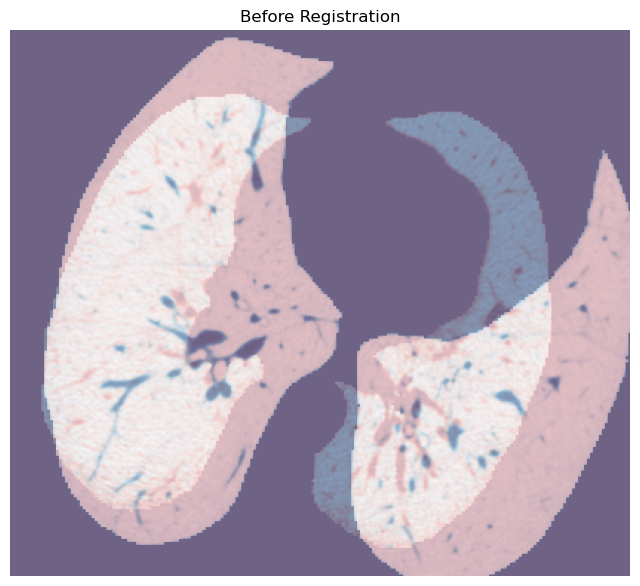

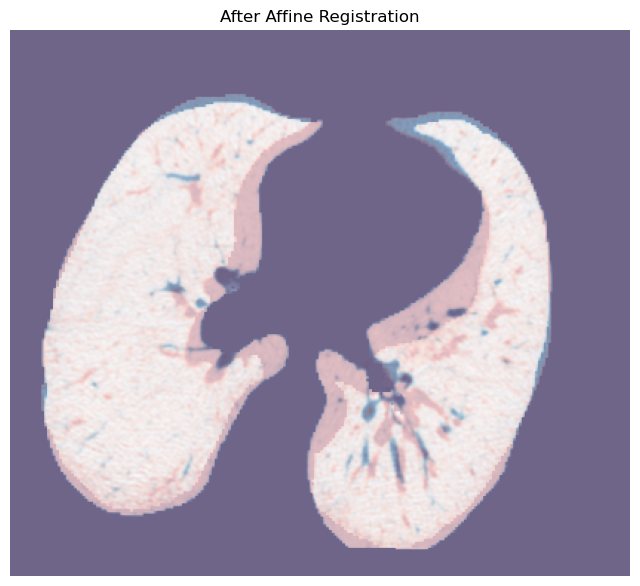

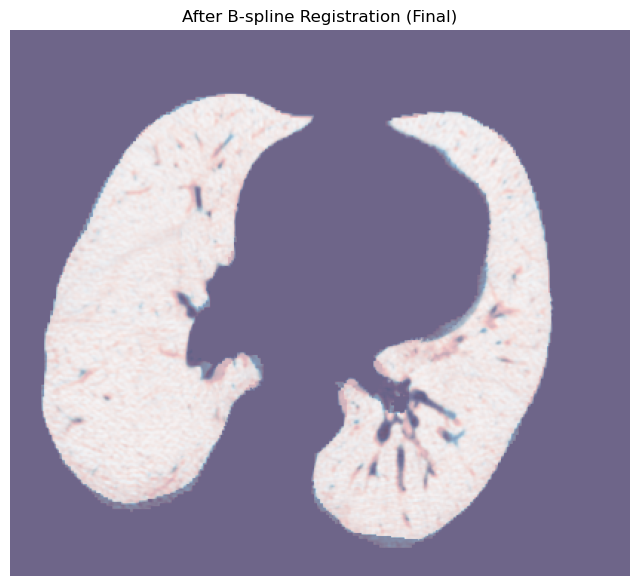

In [11]:
show_overlay(fixed_lung, moving_lung, "Before Registration")
show_overlay(fixed_lung, moving_affine, "After Affine Registration")
show_overlay(fixed_lung, moving_registered, "After B-spline Registration (Final)")


In [12]:
def mse(a, b):
    diff = sitk.GetArrayFromImage(a) - sitk.GetArrayFromImage(b)
    return np.mean(diff**2)

print("MSE Before:", mse(fixed_lung, moving_lung))
print("MSE After Affine:", mse(fixed_lung, moving_affine))
print("MSE After B-spline:", mse(fixed_lung, moving_registered))


MSE Before: 169770.64
MSE After Affine: 50827.83
MSE After B-spline: 21905.148


In [13]:
def ncc(a, b):
    A = sitk.GetArrayFromImage(a).flatten()
    B = sitk.GetArrayFromImage(b).flatten()
    return np.corrcoef(A, B)[0,1]

print("NCC Before:", ncc(fixed_lung, moving_lung))
print("NCC After Affine:", ncc(fixed_lung, moving_affine))
print("NCC After B-spline:", ncc(fixed_lung, moving_registered))


NCC Before: 0.3990713210797494
NCC After Affine: 0.7534520864905616
NCC After B-spline: 0.8862655334998264


In [14]:
from sklearn.metrics import mutual_info_score

def mutual_information(a, b):
    A = sitk.GetArrayFromImage(a).flatten()
    B = sitk.GetArrayFromImage(b).flatten()
    return mutual_info_score(A, B)

print("MI Before:", mutual_information(fixed_lung, moving_lung))
print("MI After Affine:", mutual_information(fixed_lung, moving_affine))
print("MI After B-spline:", mutual_information(fixed_lung, moving_registered))


/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


MI Before: 0.9054606801742908


/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


MI After Affine: 1.1318615973819015


/opt/tljh/user/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received multiclass values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


MI After B-spline: 1.2455224754390626


In [35]:
# ---- DICE FUNCTION ----
def dice_score(mask1, mask2):
    A = sitk.GetArrayFromImage(mask1) > 0
    B = sitk.GetArrayFromImage(mask2) > 0

    intersection = np.logical_and(A, B).sum()
    return 2 * intersection / (A.sum() + B.sum())

# ---- Resampled moving mask (you already have) ----
moving_mask_resampled = resampler.Execute(moving_mask)

# ---- Apply affine transform to mask ----
moving_mask_affine = sitk.Resample(
    moving_mask_resampled,
    fixed_mask,
    affine_transform,
    sitk.sitkNearestNeighbor,
    0.0,
    moving_mask_resampled.GetPixelID()
)

# ---- Apply B-spline transform to mask ----
moving_mask_bspline = sitk.Resample(
    moving_mask_resampled,
    fixed_mask,
    final_transform,
    sitk.sitkNearestNeighbor,
    0.0,
    moving_mask_resampled.GetPixelID()
)

# ---- Compute Dice ----
print("Dice Before:", dice_score(fixed_mask, moving_mask_resampled))
print("Dice After Affine:", dice_score(fixed_mask, moving_mask_affine))
print("Dice After B-spline:", dice_score(fixed_mask, moving_mask_bspline))


Dice Before: 0.548987212898615
Dice After Affine: 0.8156338495492244
Dice After B-spline: 0.9075866838649658


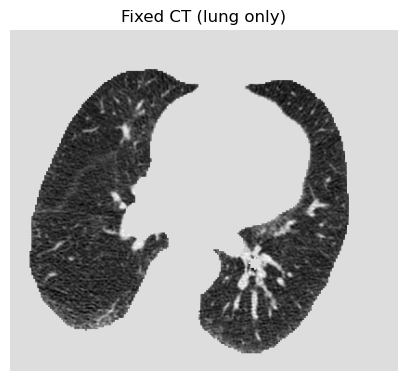

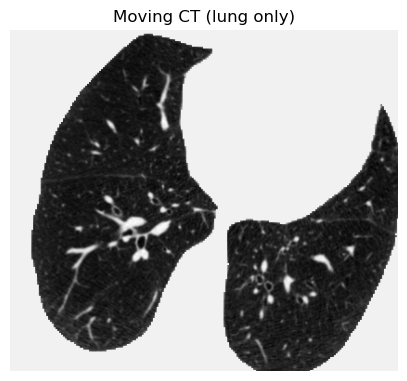

In [27]:
show_single_slice(fixed_lung, "Fixed CT (lung only)")
show_single_slice(moving_lung, "Moving CT (lung only)")


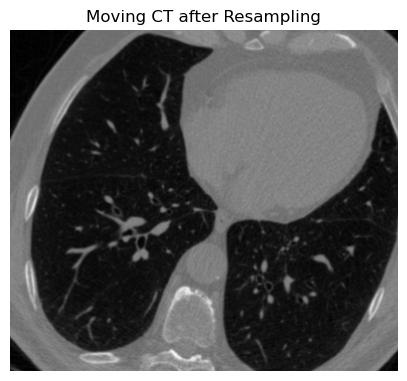

In [28]:
show_single_slice(moving_common, "Moving CT after Resampling")


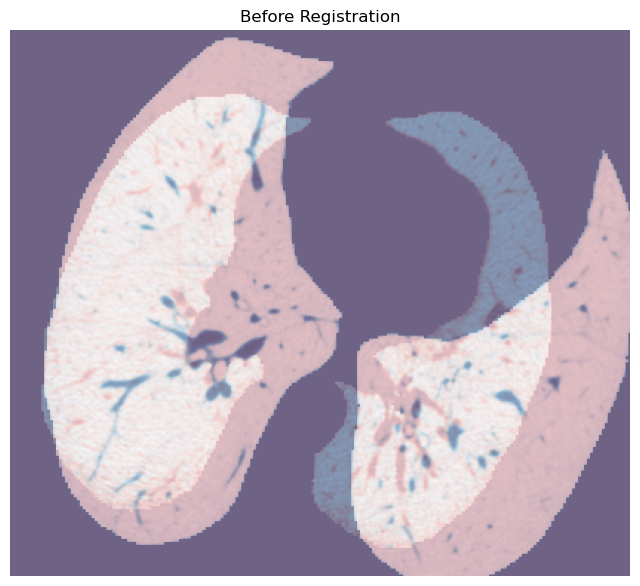

In [29]:
show_overlay(fixed_lung, moving_lung, "Before Registration")


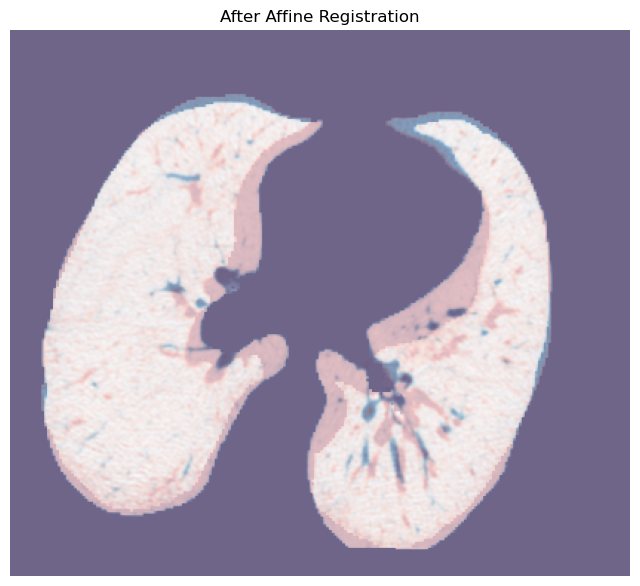

In [30]:
show_overlay(fixed_lung, moving_affine, "After Affine Registration")


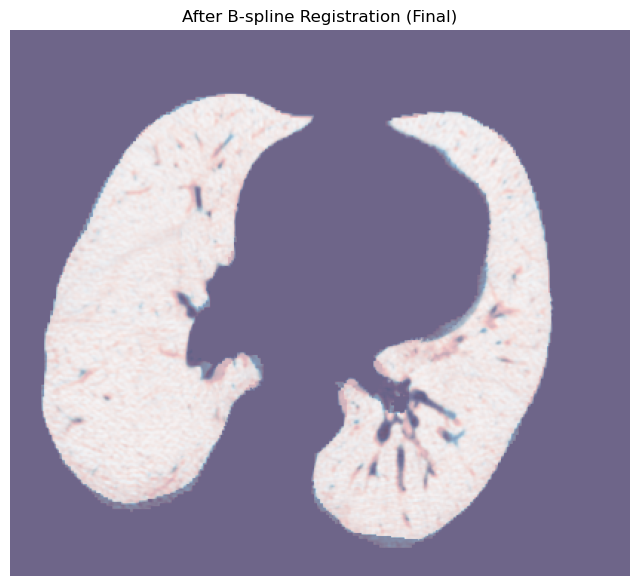

In [31]:
show_overlay(fixed_lung, moving_registered, "After B-spline Registration (Final)")


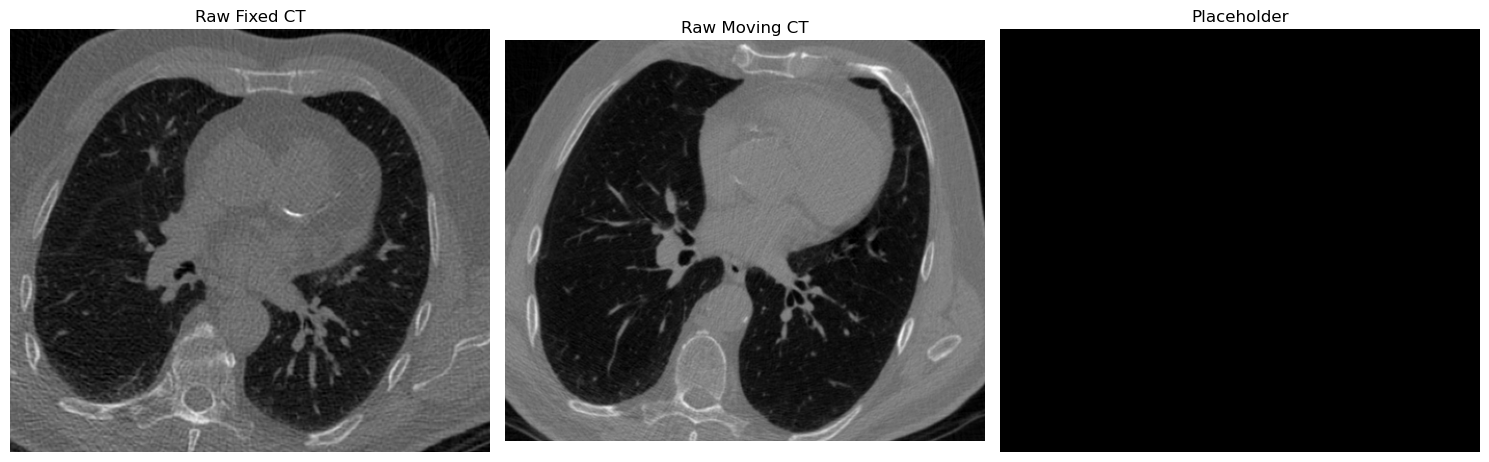

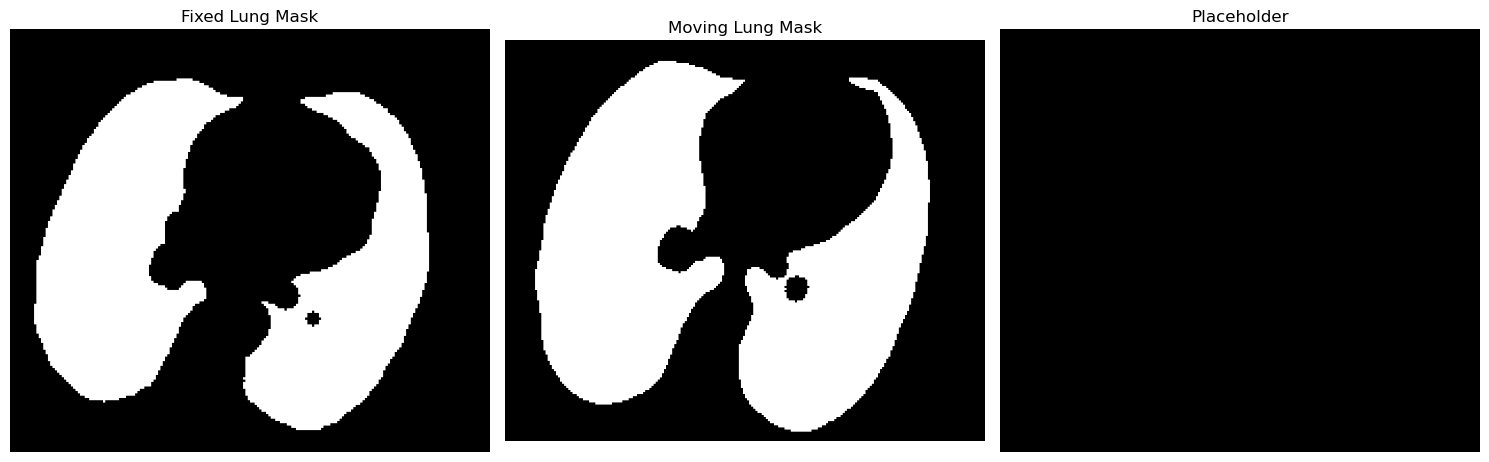

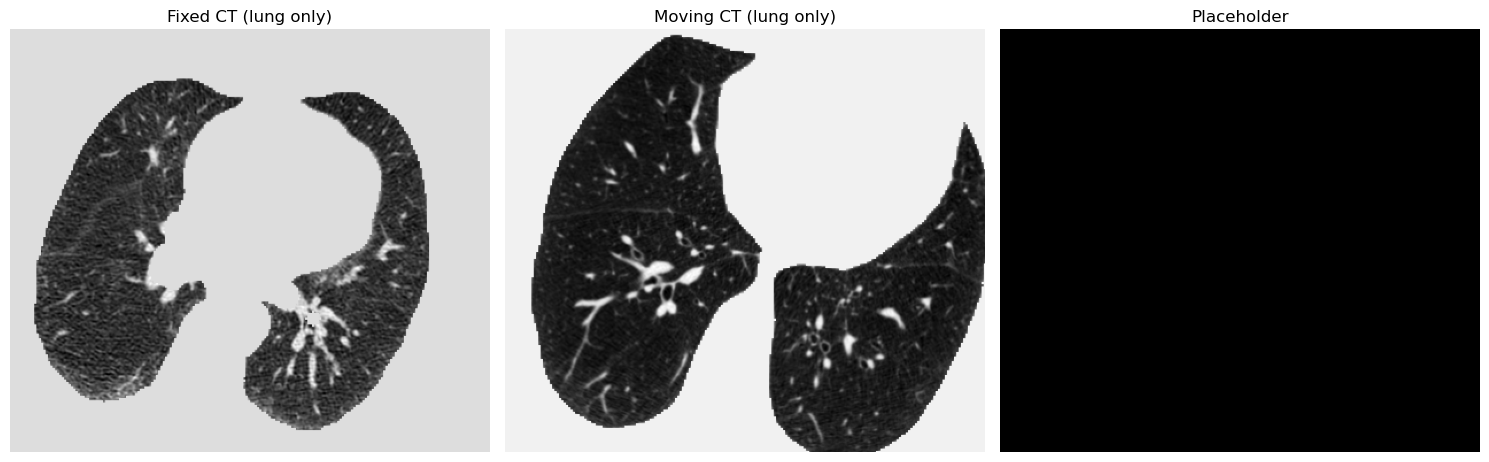

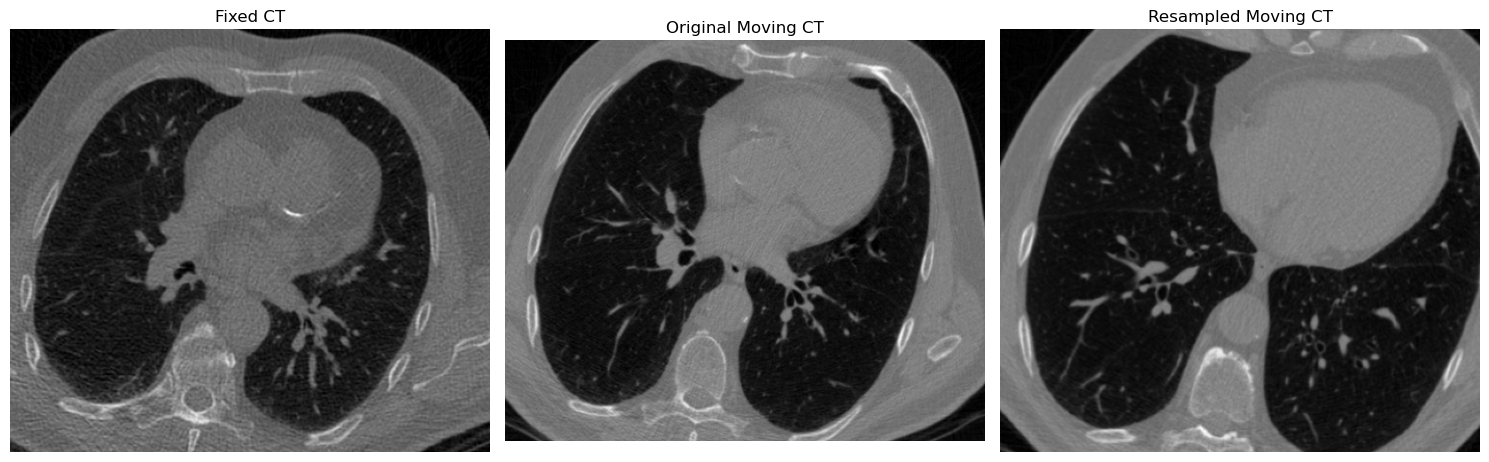

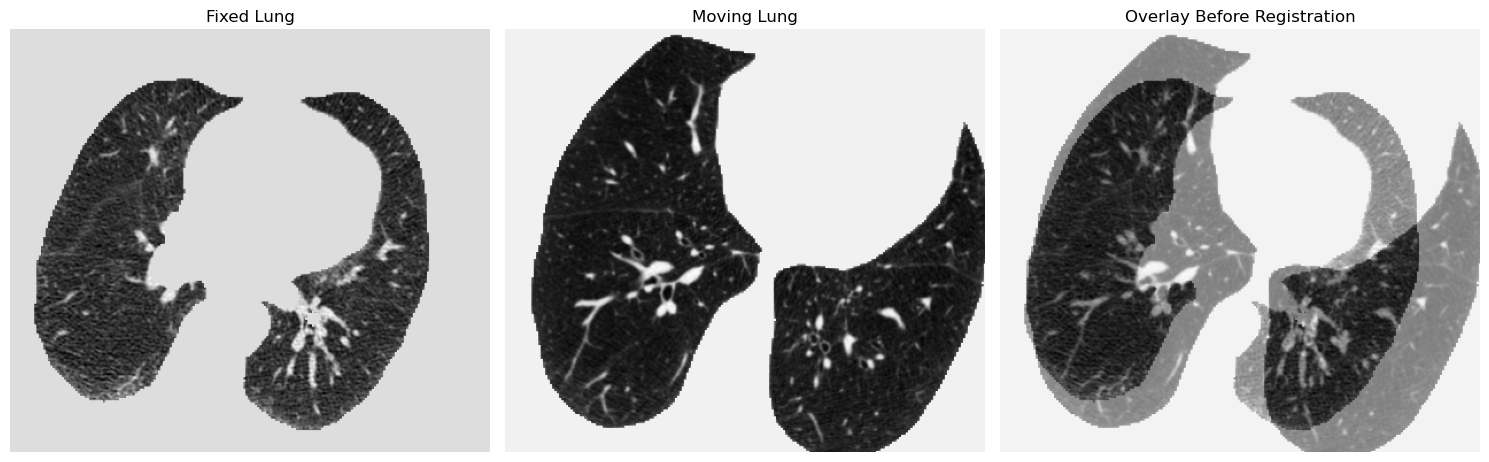

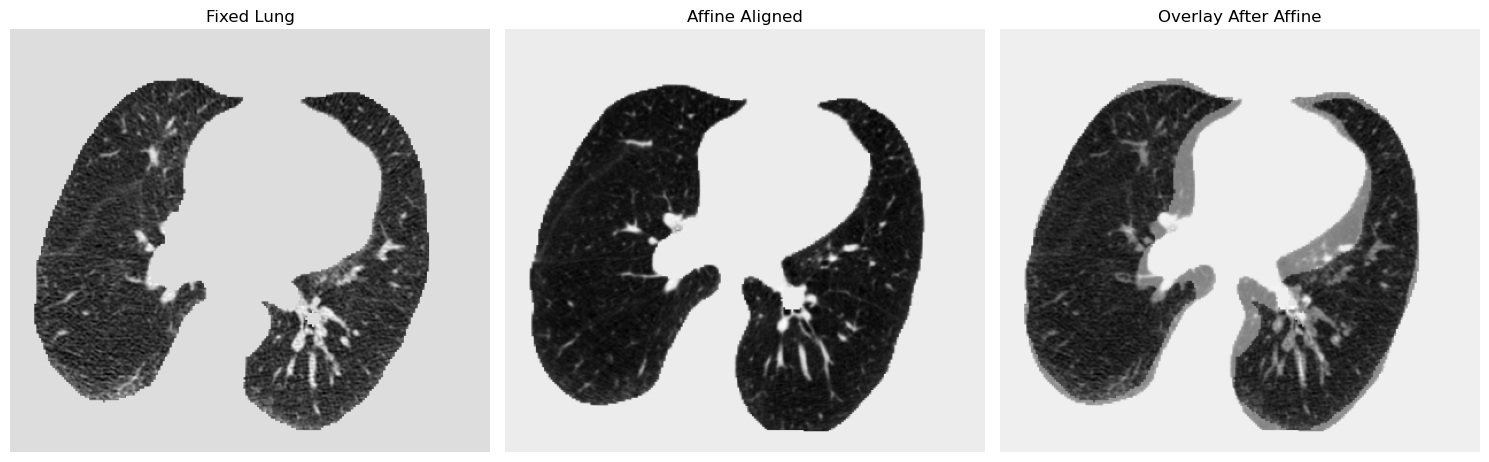

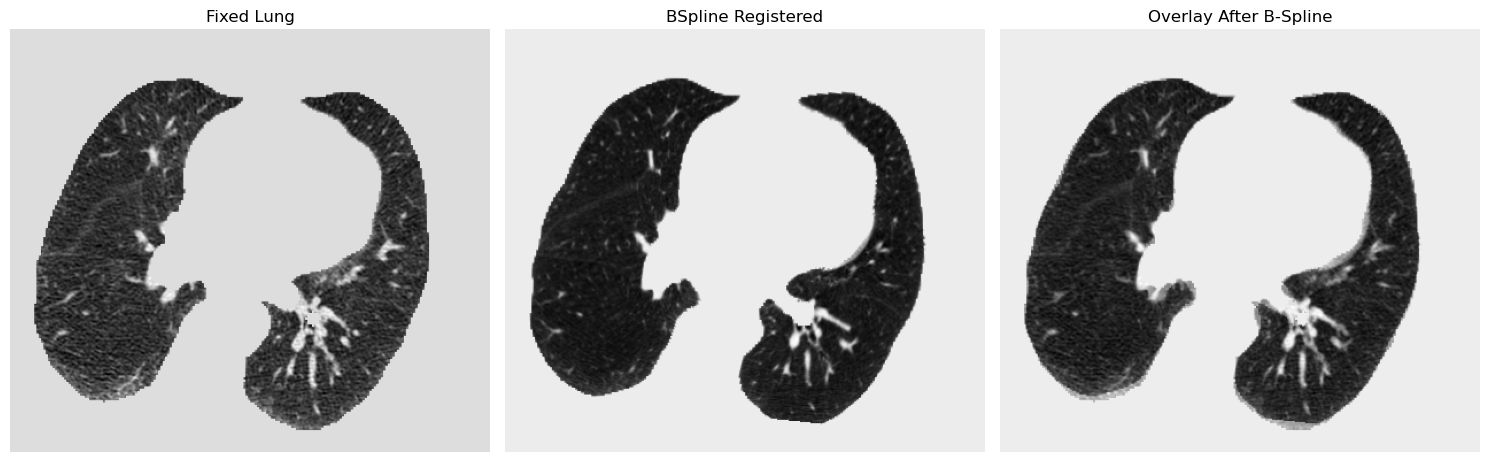

In [33]:
import os
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np

# ================================
# Create output directory
# ================================
save_dir = "Results"
os.makedirs(save_dir, exist_ok=True)

# ================================
# Helper: show axial slice
# ================================
def get_axial_slice(image):
    arr = sitk.GetArrayFromImage(image)
    z = arr.shape[0] // 2
    return arr[z, :, :]

# ================================
# Helper: save side-by-side figure
# ================================
def save_triplet(img1, img2, img3, title1, title2, title3, filename):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img1, cmap='gray')
    plt.title(title1)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img2, cmap='gray')
    plt.title(title2)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img3, cmap='gray')
    plt.title(title3)
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, filename), dpi=200, bbox_inches='tight')
    plt.show()

# ================================
# PART 1: Raw CT Inputs
# ================================
fixed_slice = get_axial_slice(fixed)
moving_slice = get_axial_slice(moving)

save_triplet(
    fixed_slice, moving_slice, np.zeros_like(fixed_slice),
    "Raw Fixed CT", "Raw Moving CT", "Placeholder",
    "01_raw_inputs.png"
)

# ================================
# PART 2: Lung Masks
# ================================
fixed_mask = sitk.ReadImage("lungMasks/01_Fixed.mhd")
moving_mask = sitk.ReadImage("lungMasks/01_Moving.mhd")

fixed_mask_slice = get_axial_slice(fixed_mask)
moving_mask_slice = get_axial_slice(moving_mask)

save_triplet(
    fixed_mask_slice, moving_mask_slice, np.zeros_like(fixed_mask_slice),
    "Fixed Lung Mask", "Moving Lung Mask", "Placeholder",
    "02_lung_masks.png"
)

# ================================
# PART 3: Masked CTs
# ================================
fixed_lung_slice = get_axial_slice(fixed_lung)
moving_lung_slice = get_axial_slice(moving_lung)

save_triplet(
    fixed_lung_slice, moving_lung_slice, np.zeros_like(fixed_lung_slice),
    "Fixed CT (lung only)", "Moving CT (lung only)", "Placeholder",
    "03_masked_cts.png"
)

# ================================
# PART 4: Resampled Moving CT
# ================================
moving_common_slice = get_axial_slice(moving_common)

save_triplet(
    fixed_slice, moving_slice, moving_common_slice,
    "Fixed CT", "Original Moving CT", "Resampled Moving CT",
    "04_resampled_moving.png"
)

# ================================
# PART 5: Overlays (Before, Affine, Final)
# ================================
def overlay(fixed_img, moving_img):
    f = get_axial_slice(fixed_img)
    m = get_axial_slice(moving_img)
    return f, m, (0.5*f + 0.5*m)

bef_f, bef_m, bef_overlay = overlay(fixed_lung, moving_lung)
aff_f, aff_m, aff_overlay = overlay(fixed_lung, moving_affine)
bs_f, bs_m, bs_overlay = overlay(fixed_lung, moving_registered)

save_triplet(
    bef_f, bef_m, bef_overlay,
    "Fixed Lung", "Moving Lung", "Overlay Before Registration",
    "05_before_registration.png"
)

save_triplet(
    aff_f, aff_m, aff_overlay,
    "Fixed Lung", "Affine Aligned", "Overlay After Affine",
    "06_after_affine.png"
)

save_triplet(
    bs_f, bs_m, bs_overlay,
    "Fixed Lung", "BSpline Registered", "Overlay After B-Spline",
    "07_after_bspline.png"
)
